# Analysis Script

## Setup

In [3]:
# Run in terminal
# cd /work/MikkelKrøjerSvendsen#1451 && source eeg/CogNeuro2025/EEG_LAB/env/bin/activate && bash eeg/CogNeuro2025/EEG_LAB/env_to_jupyter.sh
# reload browser
# choose recommended kernel

import mne
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
%matplotlib inline

# colours for plots
color1 = "#749E84"
color1_light = "#8BB39A"
color2 = "#915E86"
color2_light = "#B98DB5"

# read data
epochs = mne.read_epochs("participant-own-long-epo.fif", preload=True)
print(epochs.event_id)
print(epochs.events.shape[0])

Reading /work/MikkelKrøjerSvendsen#1451/eeg_emotional_stroop/participant-own-long-epo.fif ...
    Found the data of interest:
        t =    -400.00 ...     500.00 ms
        0 CTF compensation matrices available
Not setting metadata
414 matching events found
No baseline correction applied
0 projection items activated
{'face/congruent': 30, 'face/incongruent': 31, 'word/congruent': 20, 'word/incongruent': 21}
414


<bound method BaseEpochs.drop_log_stats of <EpochsFIF | 414 events (all good), -0.4 – 0.5 s (baseline -0.4 – 0 s), ~85.4 MiB, data loaded,
 'face/congruent': 89
 'face/incongruent': 73
 'word/congruent': 127
 'word/incongruent': 125>>


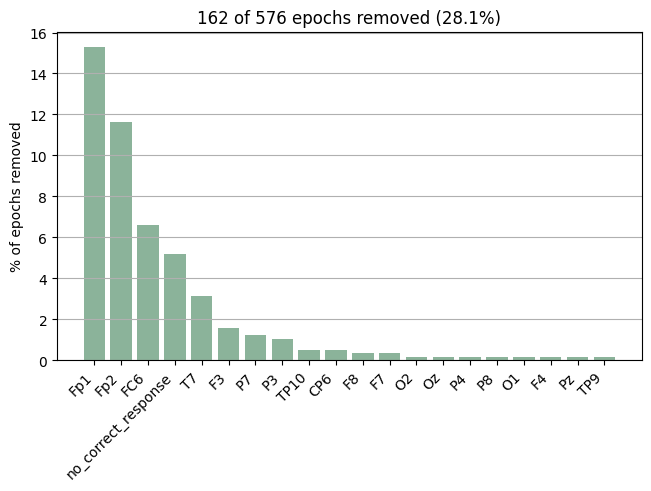

In [4]:
print(epochs.drop_log_stats)
epochs.plot_drop_log(color=color1_light);

In [5]:
# system and software version info
# !python -c "import mne; mne.sys_info()"

## Parameters

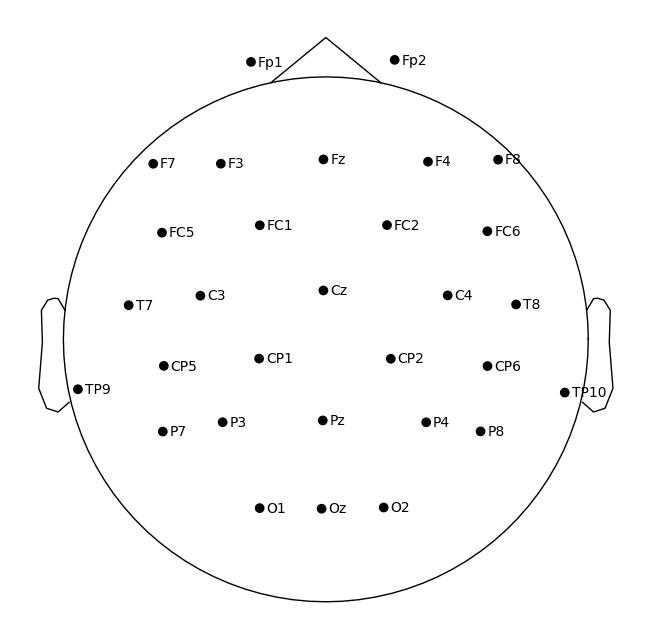

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']


In [6]:
epochs.plot_sensors(show_names=True)
print(epochs.ch_names)

picks_left = ["P7",]
picks_right = ["P8",]
picks = picks_left + picks_right

# N170 time window
tmin, tmax = 0.14, 0.20

# Matched fixation window for sanity check
tmin_null = -0.4 + tmin
tmax_null = -0.4 + tmax

## Sanity Check

Stimulus vs. fixation window:
TtestResult(statistic=np.float64(11.43065527908596), pvalue=np.float64(3.4061053561603826e-28), df=np.float64(826.0))


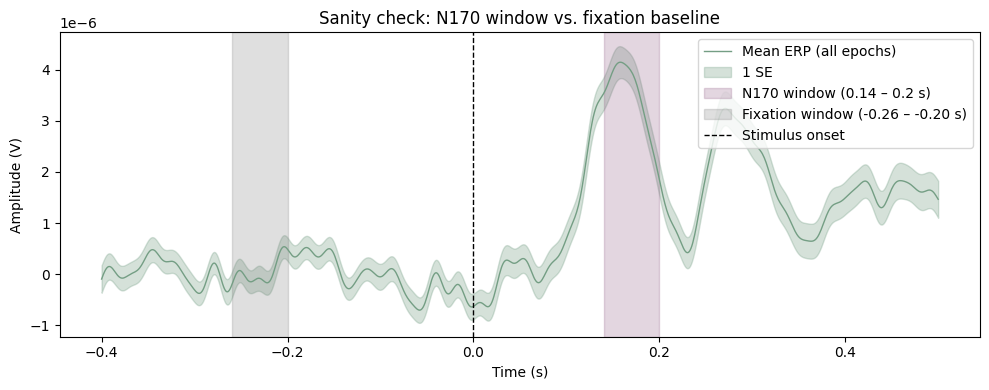

In [7]:
data_stimulus = epochs.get_data(picks=picks, tmin=tmin, tmax=tmax).mean(axis=(1, 2))
data_fixation = epochs.get_data(picks=picks, tmin=tmin_null, tmax=tmax_null).mean(axis=(1, 2))

print("Stimulus vs. fixation window:")
print(stats.ttest_ind(data_stimulus, data_fixation))

# Plot
# Average across electrodes, keep epochs separate
plot_data_by_epoch = epochs.get_data(picks=picks).mean(axis=1)  # shape: (n_epochs, n_times)

mean_erp = plot_data_by_epoch.mean(axis=0)
se_erp = plot_data_by_epoch.std(axis=0) / np.sqrt(plot_data_by_epoch.shape[0])
times = epochs.times

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, mean_erp, linewidth=1, label="Mean ERP (all epochs)", color=color1) # grand average
ax.fill_between(times, mean_erp - se_erp, mean_erp + se_erp, alpha=0.3, label="1 SE", color=color1) # se fill
ax.axvspan(tmin, tmax, alpha=0.25, label=f"N170 window ({tmin} – {tmax} s)", color=color2) # stim area
ax.axvspan(tmin_null, tmax_null, alpha=0.25, color="gray", label=f"Fixation window ({tmin_null:.2f} – {tmax_null:.2f} s)") # fixation area
ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Stimulus onset")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (V)")
ax.set_title("Sanity check: N170 window vs. fixation baseline")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

Stimulus vs. fixation window (P7):
TtestResult(statistic=np.float64(12.993811855370282), pvalue=np.float64(2.9292399556612626e-35), df=np.float64(826.0))
Stimulus vs. fixation window (P8):
TtestResult(statistic=np.float64(-3.5072026027398273), pvalue=np.float64(0.0004772800146857984), df=np.float64(826.0))


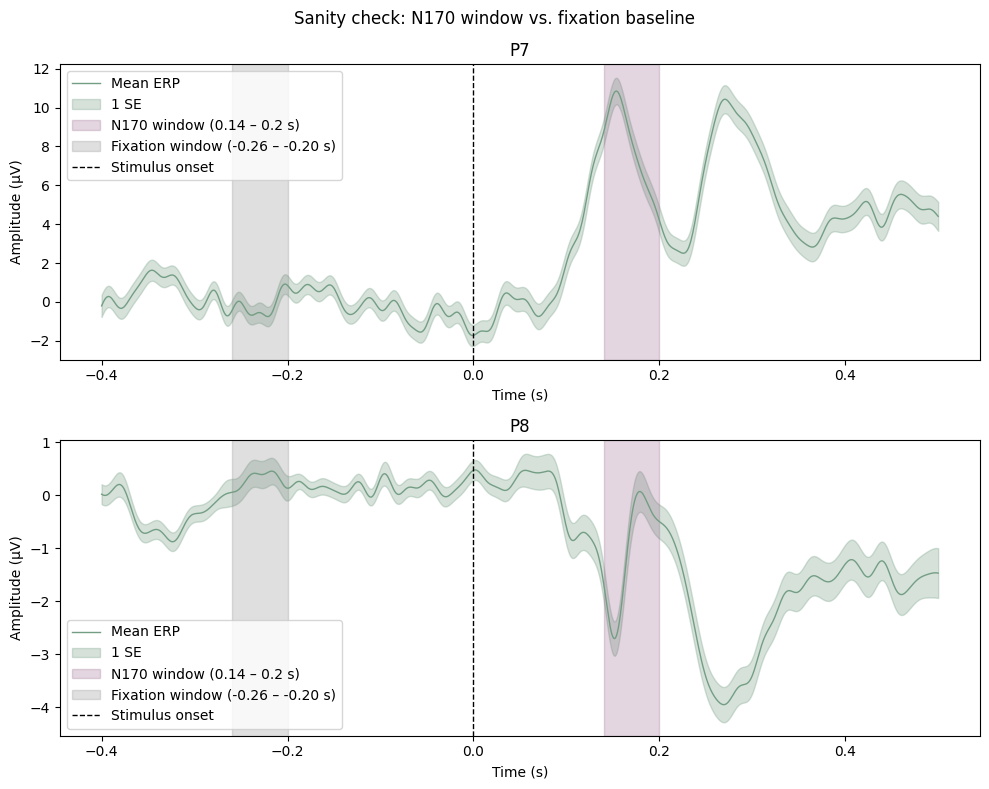

In [8]:
picks_separate = {'P7': ['P7'], 'P8': ['P8']}
legend_locs = {'P7': 'upper left', 'P8': 'lower left'}

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=False)

for ax, (ch_name, ch_picks) in zip(axes, picks_separate.items()):
    # T-test
    data_stimulus = epochs.get_data(picks=ch_picks, tmin=tmin, tmax=tmax).mean(axis=(1, 2))
    data_fixation = epochs.get_data(picks=ch_picks, tmin=tmin_null, tmax=tmax_null).mean(axis=(1, 2))
    t_result = stats.ttest_ind(data_stimulus, data_fixation)
    print(f"Stimulus vs. fixation window ({ch_name}):")
    print(t_result)

    # Plot
    plot_data_by_epoch = epochs.get_data(picks=ch_picks).mean(axis=1) * 1e6  # V --> µV
    mean_erp = plot_data_by_epoch.mean(axis=0)
    se_erp = plot_data_by_epoch.std(axis=0) / np.sqrt(plot_data_by_epoch.shape[0])
    times = epochs.times

    ax.plot(times, mean_erp, linewidth=1, label=f"Mean ERP",  color=color1) # line
    ax.fill_between(times, mean_erp - se_erp, mean_erp + se_erp, alpha=0.3, label="1 SE", color=color1) # se fill
    ax.axvspan(tmin, tmax, alpha=0.25, label=f"N170 window ({tmin} – {tmax} s)", color=color2) # stim area
    ax.axvspan(tmin_null, tmax_null, alpha=0.25, label=f"Fixation window ({tmin_null:.2f} – {tmax_null:.2f} s)", color="gray") # fixation area
    ax.axvline(x=0, color="black", linestyle="--", linewidth=1, label="Stimulus onset")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(f"{ch_name}")
    ax.legend(loc=legend_locs[ch_name])

fig.suptitle("Sanity check: N170 window vs. fixation baseline")
plt.tight_layout()
plt.show()

## Trial-level df

In [9]:
def build_trial_df(epochs, picks_left, picks_right, tmin, tmax, participant_id):
    rows = []
    global_trial_num = 0
    for condition in ['word/congruent', 'word/incongruent', 'face/congruent', 'face/incongruent']:
        ep = epochs[condition]
        left_means  = ep.get_data(picks=picks_left,  tmin=tmin, tmax=tmax).mean(axis=(1, 2))
        right_means = ep.get_data(picks=picks_right, tmin=tmin, tmax=tmax).mean(axis=(1, 2))
        task, congruency = condition.split('/')
        for condition_trial_num, (l, r) in enumerate(zip(left_means, right_means)):
            base = {'participant': participant_id, 'task': task, 'congruency': congruency,
                    'condition_trial_num': condition_trial_num, 'global_trial_num': global_trial_num}
            rows.append({**base, 'hemisphere': 'left',  'amplitude': l * 1e6})
            rows.append({**base, 'hemisphere': 'right', 'amplitude': r * 1e6})
            global_trial_num += 1
    return pd.DataFrame(rows)

df = build_trial_df(epochs, picks_left, picks_right, tmin, tmax, participant_id='p1')
print(df.groupby(['task', 'congruency', 'hemisphere'])['amplitude'].agg(['mean', 'sem']).round(3))
df.head()

                               mean    sem
task congruency  hemisphere               
face congruent   left        10.386  1.334
                 right       -0.962  1.198
     incongruent left         4.625  1.408
                 right       -1.128  0.756
word congruent   left         8.495  0.875
                 right       -1.298  0.347
     incongruent left         8.053  0.902
                 right       -0.915  0.293


,participant,task,congruency,condition_trial_num,global_trial_num,hemisphere,amplitude
0,p1,word,congruent,0,0,left,20.937891
1,p1,word,congruent,0,0,right,-1.392728
2,p1,word,congruent,1,1,left,5.917782
3,p1,word,congruent,1,1,right,-4.874637
4,p1,word,congruent,2,2,left,25.574243


In [10]:
print(df.shape)

print("n trials:", df.shape[0] / 2)

print(df.groupby(["task", "congruency"]).size() / 2)

(828, 7)
n trials: 414.0
task  congruency 
face  congruent       89.0
      incongruent     73.0
word  congruent      127.0
      incongruent    125.0
dtype: float64


## H3: Lateralization by task

In [11]:
# NOT strictly necessary given linear model below
for task in ['face', 'word']:
    left  = df[(df.task == task) & (df.hemisphere == 'left') ]['amplitude'].values
    right = df[(df.task == task) & (df.hemisphere == 'right')]['amplitude'].values
    t, p = stats.ttest_rel(left, right)  # paired t-test: same trials, different hemispheres
    print(f"{task}: left M = {left.mean():.3f}, right M = {right.mean():.3f}, t = {t:.3f}, p = {p:.3f}")

face: left M = 7.790, right M = -1.037, t = 6.007, p = 0.000
word: left M = 8.276, right M = -1.108, t = 12.916, p = 0.000


## H4: Task * congruency * hemisphere interaction

In [12]:
model_mm = smf.mixedlm("amplitude ~ task*congruency*hemisphere", data=df,
                    groups=df["global_trial_num"]).fit()

/work/MikkelKrøjerSvendsen#1451/eeg/CogNeuro2025/EEG_LAB/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/work/MikkelKrøjerSvendsen#1451/eeg/CogNeuro2025/EEG_LAB/env/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/work/MikkelKrøjerSvendsen#1451/eeg/CogNeuro2025/EEG_LAB/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/work/MikkelKrøjerSvendsen#1451/eeg/CogNeuro2025/EEG_LAB/env/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/work/MikkelKrøjerSve

This model does not converge (nor when amp is standardized). Gives similar estimates to the OLS model tho.

In [13]:
print(model_mm.summary())

                                 Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                amplitude 
No. Observations:                  828                    Method:                            REML      
No. Groups:                        414                    Scale:                             79.8511   
Min. group size:                   2                      Log-Likelihood:                    -2989.5449
Max. group size:                   2                      Converged:                         No        
Mean group size:                   2.0                                                                 
-------------------------------------------------------------------------------------------------------
                                                            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------------------------------------------

In [14]:
# doing OLS instead
model_ols = smf.ols("amplitude ~ task*congruency*hemisphere", data=df).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              amplitude   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     32.95
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.75e-40
Time:                        16:17:05   Log-Likelihood:                -2992.1
No. Observations:                 828   AIC:                             6000.
Df Residuals:                     820   BIC:                             6038.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Congruency effects

task hemisphere  congruency_effect    se  ci_low  ci_high      t      df     p  n_cong  n_incong
face       left             -5.760 1.939  -9.591   -1.930 -2.971 156.268 0.003      89        73
face      right             -0.167 1.417  -2.967    2.634 -0.118 144.076 0.907      89        73
word       left             -0.442 1.257  -2.917    2.034 -0.352 249.638 0.725     127       125
word      right              0.383 0.454  -0.512    1.278  0.844 243.599 0.400     127       125

2x2 (congruency effect, µV; more negative = larger N170 effect):
hemisphere   left  right
task                    
face       -5.760 -0.167
word       -0.442  0.383


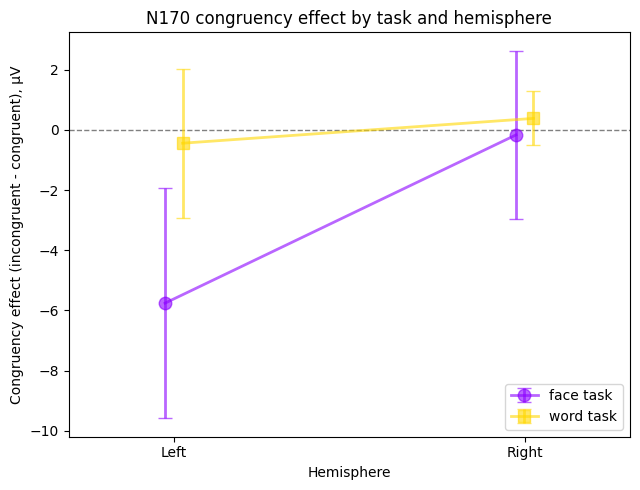

In [15]:
# Interpreting the 3-way int

# Per task x hemisphere: congruency effect (incongruent - congruent) with 95% CI.
# Congruent and incongruent are different trials, so within each task x hemisphere
# cell this is an unpaired (Welch) difference of means. N170 is
# negative, so more negative effect = a LARGER N170 congruency effect.

def congruency_effects(df, alpha=0.05):
    out = []
    for task in ['face', 'word']:
        for hemi in ['left', 'right']:
            cell = df[(df.task == task) & (df.hemisphere == hemi)]
            cong   = cell[cell.congruency == 'congruent']['amplitude'].values
            incong = cell[cell.congruency == 'incongruent']['amplitude'].values
            diff = incong.mean() - cong.mean()
            se = np.sqrt(incong.var(ddof=1)/len(incong) + cong.var(ddof=1)/len(cong))
            dfree = (se**4) / (
                (incong.var(ddof=1)/len(incong))**2/(len(incong)-1) +
                (cong.var(ddof=1)/len(cong))**2/(len(cong)-1))
            tcrit = stats.t.ppf(1 - alpha/2, dfree)
            t_stat = diff / se
            p_val = 2 * stats.t.sf(np.abs(t_stat), dfree)
            out.append({'task': task, 'hemisphere': hemi,
                        'congruency_effect': diff, 'se': se,
                        'ci_low': diff - tcrit*se, 'ci_high': diff + tcrit*se,
                        't': t_stat, 'df': dfree, 'p': p_val,
                        'n_cong': len(cong), 'n_incong': len(incong)})
    return pd.DataFrame(out)

tbl = congruency_effects(df)
print(tbl.round(3).to_string(index=False))
print("\n2x2 (congruency effect, µV; more negative = larger N170 effect):")
print(tbl.pivot(index='task', columns='hemisphere', values='congruency_effect').round(3))

# plot
fig, ax = plt.subplots(figsize=(6.5, 5))

hemis, xpos = ['left', 'right'], [0, 1]
colors  = {'face': '#8B00FF', 'word': '#FFD700'}
markers = {'face': 'o',       'word': 's'}
jitter = 0.025
offsets = {'face': -jitter, 'word': +jitter}

for task in ['face', 'word']:
    sub  = tbl[tbl.task == task].set_index('hemisphere').loc[hemis]
    y    = sub['congruency_effect'].values
    yerr = np.abs(sub[['ci_low', 'ci_high']].values.T - y)
    xpos_j = [x + offsets[task] for x in xpos]
    ax.errorbar(xpos_j, y, yerr=yerr, marker=markers[task], color=colors[task], alpha = .6,
                markersize=9, linewidth=2, capsize=5, label=f'{task} task')
ax.axhline(0, color='gray', lw=1, ls='--', zorder=0)
ax.set_xticks(xpos); ax.set_xticklabels(['Left', 'Right']); ax.set_xlim(-0.3, 1.3)
ax.set_xlabel('Hemisphere')
ax.set_ylabel('Congruency effect (incongruent - congruent), µV')
#ax.invert_yaxis()  # negative = larger N170, so larger effects point up
ax.legend(frameon=True)
ax.set_title('N170 congruency effect by task and hemisphere')
fig.tight_layout()
plt.show()

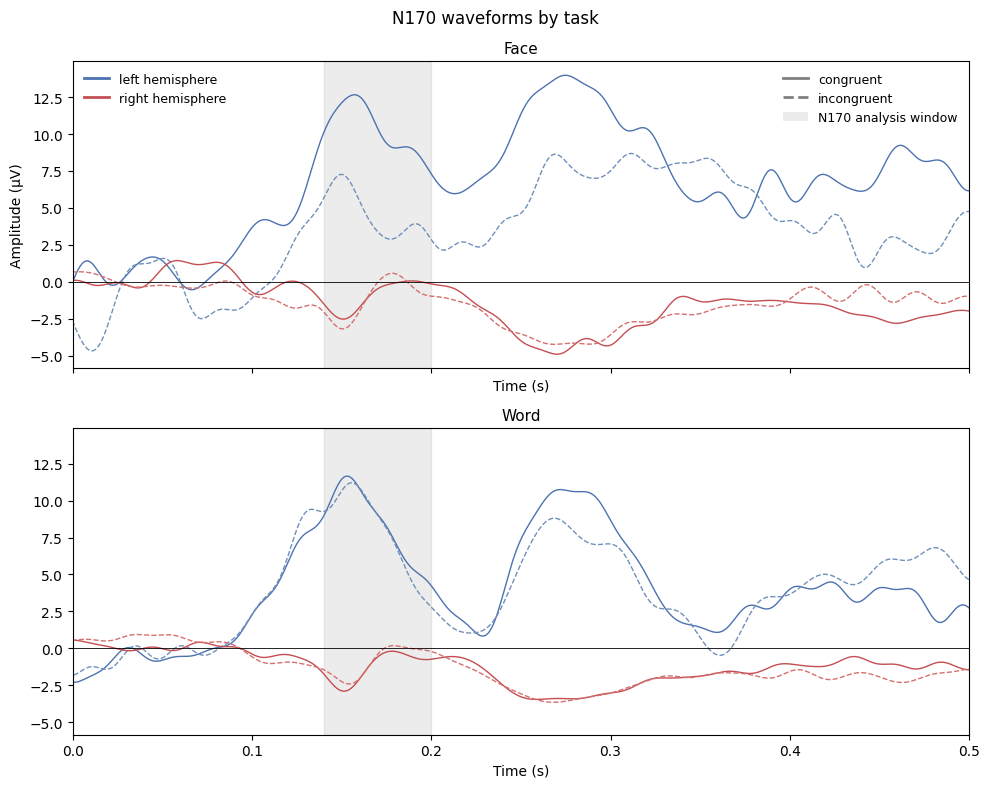

In [16]:
hemi_picks = {'left': picks_left, 'right': picks_right}

hemi_color = {
    'left':  {'congruent': '#4C72B0', 'incongruent': '#7090BA'},
    'right': {'congruent': '#C44E52', 'incongruent': '#D4706F'},
}

cong_ls    = {'congruent': '-', 'incongruent': '--'}

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
for ax, task in zip(axes, ['face', 'word']):
    for hemi in ['left', 'right']:
        for cong in ['congruent', 'incongruent']:
            ev = epochs[f'{task}/{cong}'].average(picks=hemi_picks[hemi])
            wave = ev.data.mean(axis=0) * 1e6
            ax.plot(ev.times, wave, color=hemi_color[hemi][cong], ls=cong_ls[cong], linewidth=1)
    ax.axvspan(tmin, tmax, color='gray', alpha=0.15)
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(0, color='k', lw=0.6, ls=':')
    axes[0].set_xlim(0, ev.times[-1])
    ax.set_title(f'{task.capitalize()}', fontsize=11)
    ax.set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')

hemi_handles = [
    Line2D([0], [0], color=hemi_color[h]['congruent'], lw=2, label=f'{h} hemisphere')
    for h in ['left', 'right']
]

cong_handles = [
    Line2D([0], [0], color='gray', ls=cong_ls[c], lw=2, label=c)
    for c in ['congruent', 'incongruent']
] + [Patch(facecolor='gray', alpha=0.15, label='N170 analysis window')]

leg1 = axes[0].legend(handles=hemi_handles, frameon=False, fontsize=9, loc='upper left')
axes[0].add_artist(leg1)
axes[0].legend(handles=cong_handles, frameon=False, fontsize=9, loc='upper right')

fig.suptitle('N170 waveforms by task')
fig.tight_layout()
plt.show()

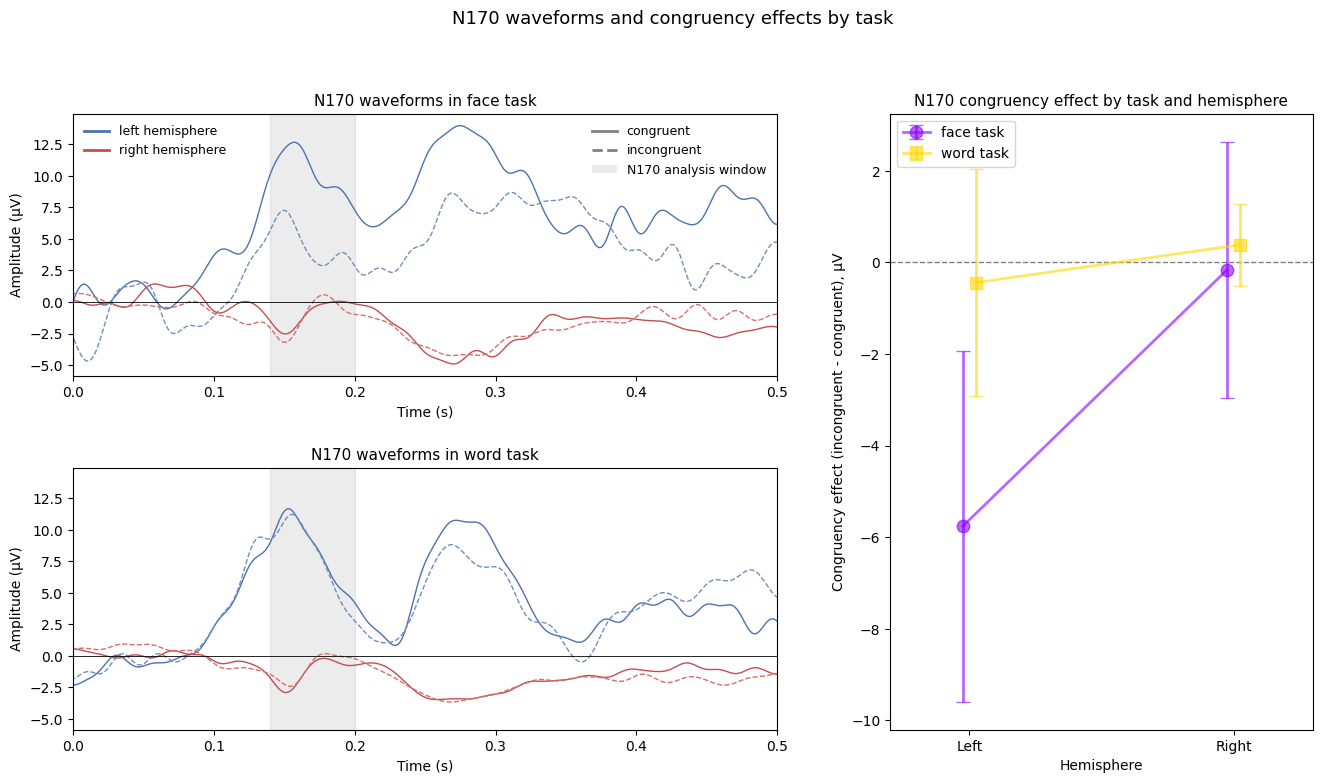

In [ ]:
fig = plt.figure(figsize=(16, 8))

# Left panel: 2-row stack; right panel: single tall axis
gs = fig.add_gridspec(2, 2, width_ratios=[5/8, 3/8], hspace=0.35, wspace=0.2)

ax_face = fig.add_subplot(gs[0, 0])
ax_word = fig.add_subplot(gs[1, 0], sharex=ax_face, sharey=ax_face)
ax_right = fig.add_subplot(gs[:, 1])

# Left panel (waveforms)
axes_left = [ax_face, ax_word]
for ax, task in zip(axes_left, ['face', 'word']):
    for hemi in ['left', 'right']:
        for cong in ['congruent', 'incongruent']:
            ev = epochs[f'{task}/{cong}'].average(picks=hemi_picks[hemi])
            wave = ev.data.mean(axis=0) * 1e6
            ax.plot(ev.times, wave, color=hemi_color[hemi][cong], ls=cong_ls[cong], linewidth=1)
    ax.axvspan(tmin, tmax, color='gray', alpha=0.15)
    ax.axhline(0, color='k', lw=0.6)
    ax.axvline(0, color='k', lw=0.6, ls=':')
    ax.set_title(f'N170 waveforms in {task} task', fontsize=11)
    ax.set_xlabel('Time (s)')

ax_face.set_xlim(0, ev.times[-1])
ax_face.set_ylabel('Amplitude (µV)')
ax_word.set_ylabel('Amplitude (µV)')

hemi_handles = [
    Line2D([0], [0], color=hemi_color[h]['congruent'], lw=2, label=f'{h} hemisphere')
    for h in ['left', 'right']
]
cong_handles = [
    Line2D([0], [0], color='gray', ls=cong_ls[c], lw=2, label=c)
    for c in ['congruent', 'incongruent']
] + [Patch(facecolor='gray', alpha=0.15, label='N170 analysis window')]

leg1 = ax_face.legend(handles=hemi_handles, frameon=False, fontsize=9, loc='upper left')
ax_face.add_artist(leg1)
ax_face.legend(handles=cong_handles, frameon=False, fontsize=9, loc='upper right')

# Right panel (congruency effect)
for task in ['face', 'word']:
    sub  = tbl[tbl.task == task].set_index('hemisphere').loc[hemis]
    y    = sub['congruency_effect'].values
    yerr = np.abs(sub[['ci_low', 'ci_high']].values.T - y)
    xpos_j = [x + offsets[task] for x in xpos]
    ax_right.errorbar(xpos_j, y, yerr=yerr, marker=markers[task], color=colors[task],
                      alpha=0.6, markersize=9, linewidth=2, capsize=5, label=f'{task} task')

ax_right.axhline(0, color='gray', lw=1, ls='--', zorder=0)
ax_right.set_xticks(xpos)
ax_right.set_xticklabels(['Left', 'Right'])
ax_right.set_xlim(-0.3, 1.3)
ax_right.set_xlabel('Hemisphere')
ax_right.set_ylabel('Congruency effect (incongruent - congruent), µV')
ax_right.legend(frameon=True)
ax_right.set_title('N170 congruency effect by task and hemisphere', fontsize=11)

fig.suptitle('N170 waveforms and congruency effects by task', fontsize=13, y=1.01)
plt.savefig('n170_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Consistency plots

Not setting metadata
162 matching events found
No baseline correction applied
0 projection items activated


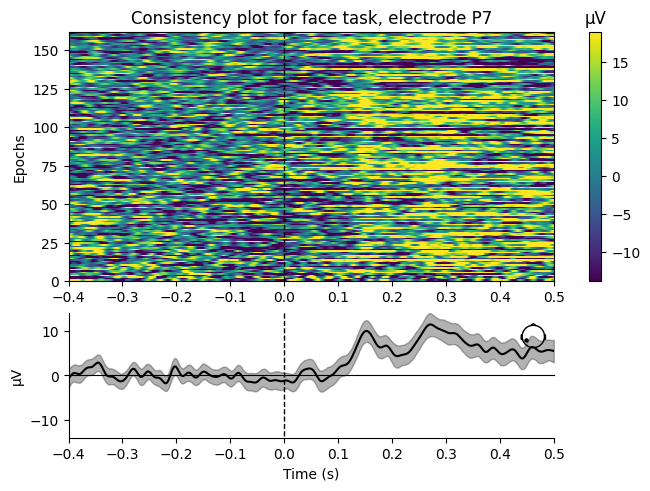

Not setting metadata
162 matching events found
No baseline correction applied
0 projection items activated


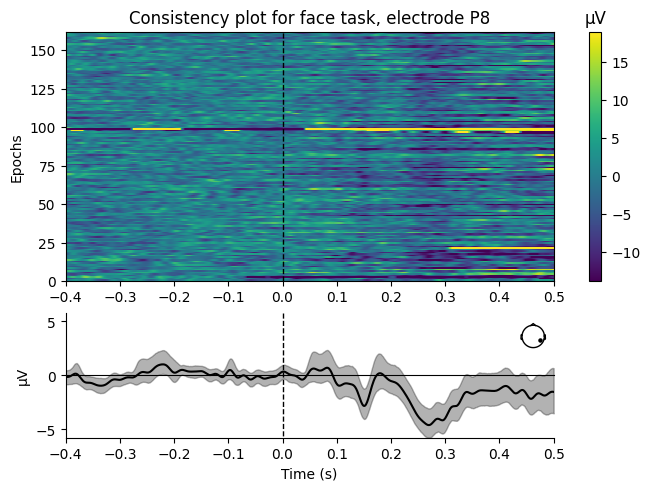

Not setting metadata
252 matching events found
No baseline correction applied
0 projection items activated


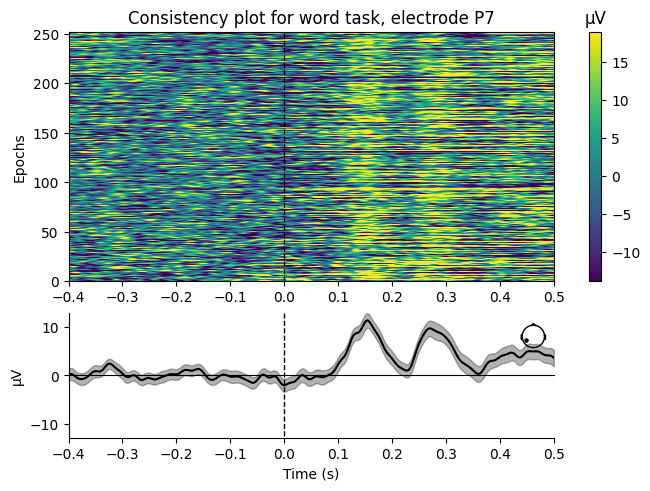

Not setting metadata
252 matching events found
No baseline correction applied
0 projection items activated


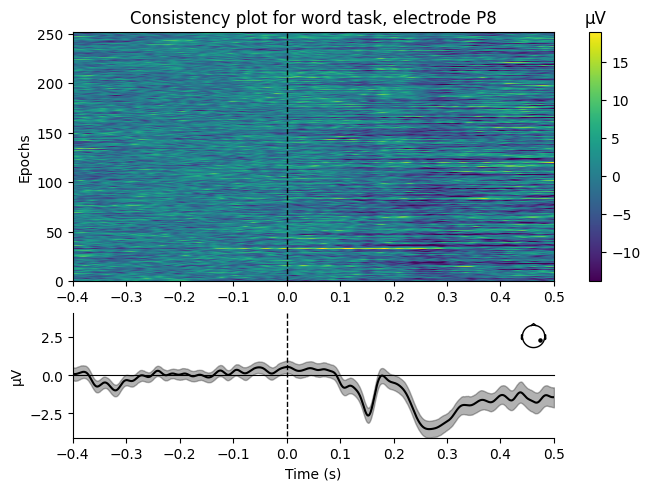

In [ ]:
data = epochs.get_data(picks=['P7', 'P8'])
vmin, vmax = np.percentile(data * 1e6, [5, 95])

for condition in ['face', 'word']:
    for pick in ['P7', 'P8']:
        epochs[condition].plot_image(picks=[pick], title=f'Consistency plot for {condition} task, electrode {pick}', vmin=vmin, vmax=vmax, cmap='viridis')

## Joint butterfly plots

No projector specified for this dataset. Please consider the method self.add_proj.


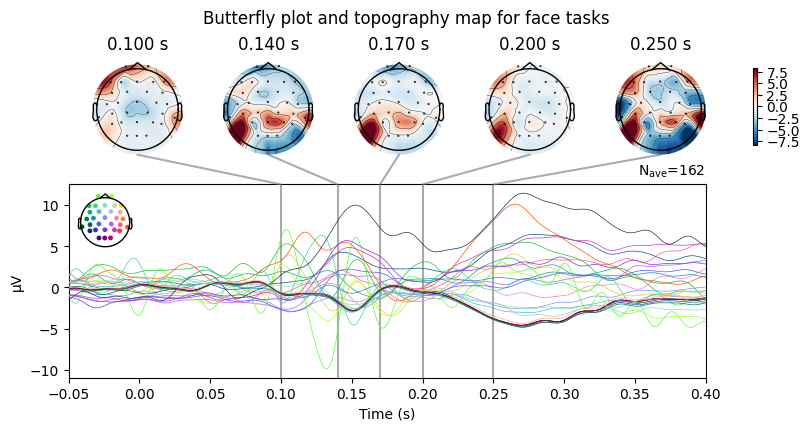

No projector specified for this dataset. Please consider the method self.add_proj.


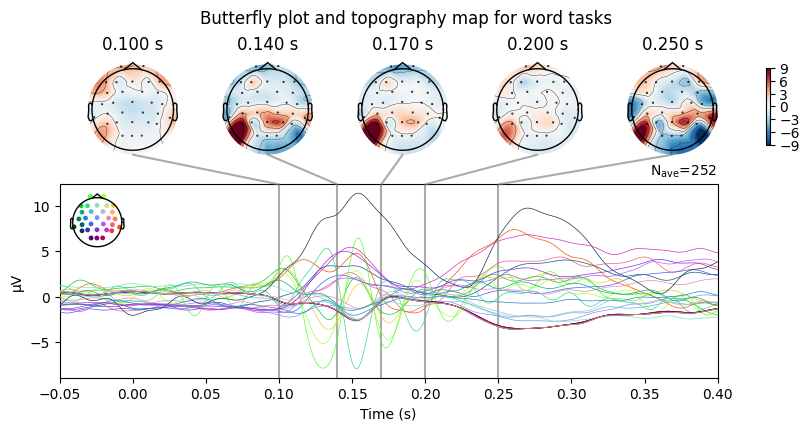

In [70]:
ts_args = {'xlim': (-0.05, 0.4)}

for condition in ['face', 'word']:
    ev = epochs[condition].average()
    ev.plot_joint(title=f"Butterfly plot and topography map for {condition} tasks", picks='eeg',
    times = [0.10, 0.14, 0.17, 0.20, 0.25],
    ts_args=ts_args)